In [32]:
import pandas as pd

In [ ]:
df = pd.read_csv('./data/bronze/HR_Analytics.csv')
df.columns = df.columns.str.strip() #Strip whitespace from the columns titles

In [34]:
#Understanding the dataset
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   EmpID                     1480 non-null   str  
 1   Age                       1480 non-null   int64
 2   AgeGroup                  1480 non-null   str  
 3   Attrition                 1480 non-null   str  
 4   BusinessTravel            1480 non-null   str  
 5   DailyRate                 1480 non-null   int64
 6   Department                1480 non-null   str  
 7   DistanceFromHome          1480 non-null   int64
 8   Education                 1480 non-null   int64
 9   EducationField            1480 non-null   str  
 10  EmployeeCount             1480 non-null   int64
 11  EmployeeNumber            1480 non-null   int64
 12  EnvironmentSatisfaction   1480 non-null   int64
 13  Gender                    1480 non-null   str  
 14  HourlyRate                1480 non-null   int64
 15

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0


In [35]:
#Checking for nulls and duplicates
df.isnull().sum()
df.duplicated().sum()

np.int64(7)

In [36]:
for col in df.columns:
    print(col, df[col].nunique())

EmpID 1470
Age 43
AgeGroup 5
Attrition 2
BusinessTravel 4
DailyRate 886
Department 3
DistanceFromHome 29
Education 5
EducationField 6
EmployeeCount 1
EmployeeNumber 1470
EnvironmentSatisfaction 4
Gender 2
HourlyRate 71
JobInvolvement 4
JobLevel 5
JobRole 9
JobSatisfaction 4
MaritalStatus 3
MonthlyIncome 1349
SalarySlab 4
MonthlyRate 1427
NumCompaniesWorked 10
Over18 1
OverTime 2
PercentSalaryHike 15
PerformanceRating 2
RelationshipSatisfaction 4
StandardHours 1
StockOptionLevel 4
TotalWorkingYears 40
TrainingTimesLastYear 7
WorkLifeBalance 4
YearsAtCompany 37
YearsInCurrentRole 19
YearsSinceLastPromotion 16
YearsWithCurrManager 19


In [37]:
df['Attrition'].value_counts()


Attrition
No           1242
Yes           238
Name: count, dtype: int64

In [38]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No           83.918919
Yes          16.081081
Name: proportion, dtype: float64

In [39]:
import seaborn as sns

<Axes: xlabel='Attrition', ylabel='count'>

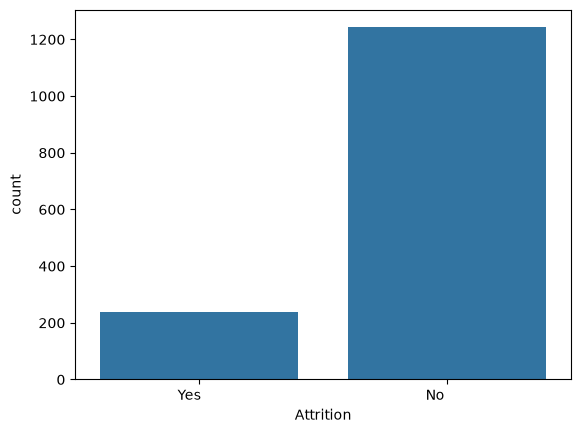

In [40]:
sns.countplot(data=df, x='Attrition')

<Axes: xlabel='Department', ylabel='Count'>

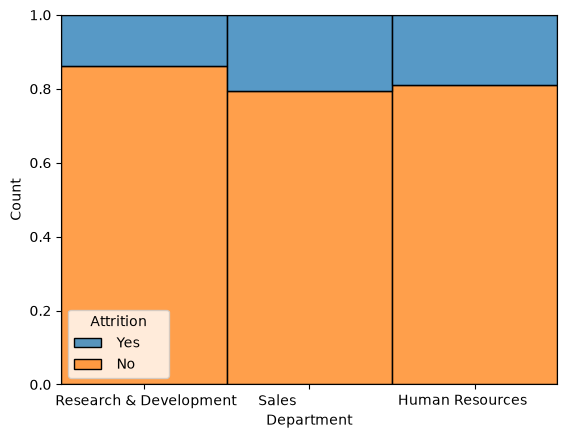

In [41]:
sns.histplot(data=df, x='Department', hue='Attrition', multiple='fill')

<Axes: xlabel='Attrition', ylabel='DistanceFromHome'>

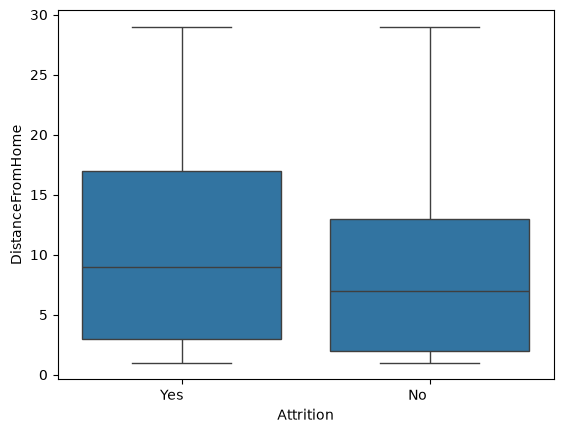

In [42]:
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')

In [43]:
pd.crosstab([df.OverTime], [df.Attrition], normalize='index')*100

Attrition,No,Yes
OverTime,,
No,89.642185,10.357815
Yes,69.377990,30.622010


In [44]:
pd.crosstab([df.Department], [df.Attrition], normalize='index')*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.246122,13.753878
Sales,79.333333,20.666667


In [45]:
pd.crosstab([df.MaritalStatus], [df.Attrition], normalize='index')*100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.634146,10.365854
Married,87.628866,12.371134
Single,74.630021,25.369979


<Axes: >

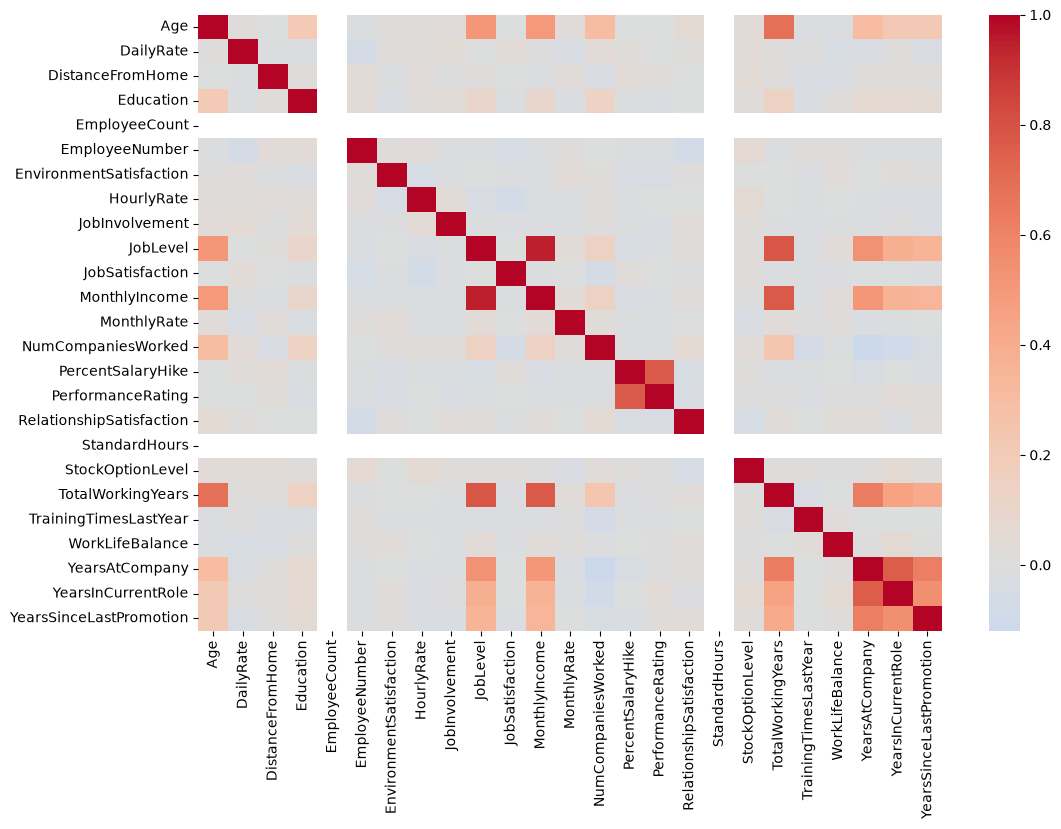

In [46]:
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(include='number')
corr = num_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr,cmap='coolwarm', center=0)

In [50]:
df['AttritionFlag'] = (
    df['Attrition']
    .str.strip()
    .map({'Yes': 1, 'No': 0})
)

In [51]:
corr_attrition = (
    df.select_dtypes(include='number')
      .corr()['AttritionFlag']
      .sort_values(ascending=False)
)

In [52]:
corr_attrition

AttritionFlag               1.000000
DistanceFromHome            0.080006
NumCompaniesWorked          0.045336
MonthlyRate                 0.016585
PerformanceRating           0.002531
HourlyRate                 -0.008252
EmployeeNumber             -0.012376
PercentSalaryHike          -0.014603
Education                  -0.030144
YearsSinceLastPromotion    -0.032244
RelationshipSatisfaction   -0.045387
DailyRate                  -0.056976
TrainingTimesLastYear      -0.058415
WorkLifeBalance            -0.062646
EnvironmentSatisfaction    -0.101696
JobSatisfaction            -0.104232
JobInvolvement             -0.130769
YearsAtCompany             -0.135108
StockOptionLevel           -0.135140
Age                        -0.155476
MonthlyIncome              -0.157672
YearsInCurrentRole         -0.160968
JobLevel                   -0.167150
TotalWorkingYears          -0.168358
EmployeeCount                    NaN
StandardHours                    NaN
Name: AttritionFlag, dtype: float64